<br><h1 style='text-align: center;'>Fake News</h1><br>
# Part 1 - Data Processing
### Task 1 - Small sample

In [1]:
#!uv add polars numpy matplotlib seaborn nltk

In [103]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

pd.set_option('display.max_columns', 200)
plt.style.use("ggplot")

In [3]:
_filepath = "./data/news_sample.csv"
df = pl.read_csv(_filepath).drop([""])  # drop the unnamed first column
# Read data
df

id,domain,type,url,content,scraped_at,inserted_at,updated_at,title,authors,keywords,meta_keywords,meta_description,tags,summary
i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str
141,"""awm.com""","""unreliable""","""http://awm.com/church-congrega…","""Sometimes the power of Christm…","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Church Congregation Brings Gif…","""Ruth Harris""",null,"""['']""",null,null,null
256,"""beforeitsnews.com""","""fake""","""http://beforeitsnews.com/awake…","""AWAKENING OF 12 STRANDS of DNA…","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""AWAKENING OF 12 STRANDS of DNA…","""Zurich Times""",null,"""['']""",null,null,null
700,"""cnnnext.com""","""unreliable""","""http://www.cnnnext.com/video/1…","""Never Hike Alone: A Friday the…","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Never Hike Alone - A Friday th…",null,null,"""['']""","""Never Hike Alone: A Friday the…",null,null
768,"""awm.com""","""unreliable""","""http://awm.com/elusive-alien-o…","""When a rare shark was caught, …","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Elusive ‘Alien Of The Sea ‘ Ca…","""Alexander Smith""",null,"""['']""",null,null,null
791,"""bipartisanreport.com""","""clickbait""","""http://bipartisanreport.com/20…","""Donald Trump has the unnerving…","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Trump’s Genius Poll Is Complet…","""Gloria Christie""",null,"""['']""",null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
39259,"""beforeitsnews.com""","""fake""","""http://beforeitsnews.com/econo…","""Prison for Rahm, God’s Work An…","""2018-01-25 20:13:50.426130""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Prison for Rahm, God’s Work An…",null,null,"""['']""",null,null,null
39468,"""beforeitsnews.com""","""fake""","""http://beforeitsnews.com/diy/2…","""4 Useful Items for Your Tiny H…","""2018-01-25 20:13:50.426130""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""4 Useful Items for Your Tiny H…","""Dimitry K""",null,"""['']""",null,null,null
39477,"""www.newsmax.com""",null,"""https://www.newsmax.com/politi…","""Former CIA Director Michael Ha…","""2018-01-25 20:13:50.426130""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Michael Hayden: We Should Be '…","""Todd Beamon""",null,"""['michael hayden', 'sthole cou…","""President Donald Trump's repor…","""Homeland Security, Trump Admin…",null


In [4]:
print(df.schema)
print(f"Shape: {df.shape}")
print(f"Null counts:\n{df.null_count()}")

Schema([('id', Int64), ('domain', String), ('type', String), ('url', String), ('content', String), ('scraped_at', String), ('inserted_at', String), ('updated_at', String), ('title', String), ('authors', String), ('keywords', String), ('meta_keywords', String), ('meta_description', String), ('tags', String), ('summary', String)])
Shape: (250, 15)
Null counts:
shape: (1, 15)
┌─────┬────────┬──────┬─────┬───┬──────────────┬──────────────┬──────┬─────────┐
│ id  ┆ domain ┆ type ┆ url ┆ … ┆ meta_keyword ┆ meta_descrip ┆ tags ┆ summary │
│ --- ┆ ---    ┆ ---  ┆ --- ┆   ┆ s            ┆ tion         ┆ ---  ┆ ---     │
│ u32 ┆ u32    ┆ u32  ┆ u32 ┆   ┆ ---          ┆ ---          ┆ u32  ┆ u32     │
│     ┆        ┆      ┆     ┆   ┆ u32          ┆ u32          ┆      ┆         │
╞═════╪════════╪══════╪═════╪═══╪══════════════╪══════════════╪══════╪═════════╡
│ 0   ┆ 0      ┆ 12   ┆ 0   ┆ … ┆ 0            ┆ 196          ┆ 223  ┆ 250     │
└─────┴────────┴──────┴─────┴───┴──────────────┴─────────

In [5]:
df_1 = (
    df.drop(["keywords", "summary"])
    .fill_null("nan")
    .with_columns(
        pl.when(pl.col("meta_keywords") == "['']")
        .then(pl.lit("nan"))
        .otherwise(pl.col("meta_keywords"))
        .alias("meta_keywords")
    )
)
df_1

id,domain,type,url,content,scraped_at,inserted_at,updated_at,title,authors,meta_keywords,meta_description,tags
i64,str,str,str,str,str,str,str,str,str,str,str,str
141,"""awm.com""","""unreliable""","""http://awm.com/church-congrega…","""Sometimes the power of Christm…","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Church Congregation Brings Gif…","""Ruth Harris""","""nan""","""nan""","""nan"""
256,"""beforeitsnews.com""","""fake""","""http://beforeitsnews.com/awake…","""AWAKENING OF 12 STRANDS of DNA…","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""AWAKENING OF 12 STRANDS of DNA…","""Zurich Times""","""nan""","""nan""","""nan"""
700,"""cnnnext.com""","""unreliable""","""http://www.cnnnext.com/video/1…","""Never Hike Alone: A Friday the…","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Never Hike Alone - A Friday th…","""nan""","""nan""","""Never Hike Alone: A Friday the…","""nan"""
768,"""awm.com""","""unreliable""","""http://awm.com/elusive-alien-o…","""When a rare shark was caught, …","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Elusive ‘Alien Of The Sea ‘ Ca…","""Alexander Smith""","""nan""","""nan""","""nan"""
791,"""bipartisanreport.com""","""clickbait""","""http://bipartisanreport.com/20…","""Donald Trump has the unnerving…","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Trump’s Genius Poll Is Complet…","""Gloria Christie""","""nan""","""nan""","""nan"""
…,…,…,…,…,…,…,…,…,…,…,…,…
39259,"""beforeitsnews.com""","""fake""","""http://beforeitsnews.com/econo…","""Prison for Rahm, God’s Work An…","""2018-01-25 20:13:50.426130""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Prison for Rahm, God’s Work An…","""nan""","""nan""","""nan""","""nan"""
39468,"""beforeitsnews.com""","""fake""","""http://beforeitsnews.com/diy/2…","""4 Useful Items for Your Tiny H…","""2018-01-25 20:13:50.426130""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""4 Useful Items for Your Tiny H…","""Dimitry K""","""nan""","""nan""","""nan"""
39477,"""www.newsmax.com""","""nan""","""https://www.newsmax.com/politi…","""Former CIA Director Michael Ha…","""2018-01-25 20:13:50.426130""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""Michael Hayden: We Should Be '…","""Todd Beamon""","""['michael hayden', 'sthole cou…","""President Donald Trump's repor…","""Homeland Security, Trump Admin…"


In [6]:
df_1.describe()

statistic,id,domain,type,url,content,scraped_at,inserted_at,updated_at,title,authors,meta_keywords,meta_description,tags
str,f64,str,str,str,str,str,str,str,str,str,str,str,str
"""count""",250.0,"""250""","""250""","""250""","""250""","""250""","""250""","""250""","""250""","""250""","""250""","""250""","""250"""
"""null_count""",0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0"""
"""mean""",20241.56,null,null,null,null,null,null,null,null,null,null,null,null
"""std""",11515.412728,null,null,null,null,null,null,null,null,null,null,null,null
"""min""",141.0,"""21stcenturywire.com""","""bias""","""http://21stcenturywire.com/201…","""(NaturalNews) If you thought B…","""2018-01-25 16:17:44.789555""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""'Stop Christie' PAC quits, say…","""A Bad Witch'S Blog""","""['', 'Big Government', 'mark l…","""'Enough meddling ... Go home, …","""Achievement Gap, GOP Share Of …"
"""25%""",11001.0,null,null,null,null,null,null,null,null,null,null,null,null
"""50%""",21093.0,null,null,null,null,null,null,null,null,null,null,null,null
"""75%""",29104.0,null,null,null,null,null,null,null,null,null,null,null,null
"""max""",39558.0,"""www.newsmax.com""","""unreliable""","""https://www.undergroundhealth.…","""“Voice or no voice, the people…","""2018-01-25 20:13:50.426130""","""2018-02-02 01:19:41.756632""","""2018-02-02 01:19:41.756664""","""“Draining the Swamp” Doesn’t M…","""nan""","""nan""","""“We are on the precipice of co…","""out of iraq, end the occupatio…"


In [7]:
# Helper function to collect tokens labeled as <OTHER>
def _collect_other(token, log):
    if log is not None:
        log.append(token)
    return "<OTHER>"


# Pattern strings — shared with Task 2 (Polars uses these directly)
email_re = re.compile(r'[^ \n,"]+@[^ \n,"]+\.[^ \n,"]+')
date_re = re.compile(r'[0-9]{2,4}[-/][0-9]{2,4}[-/][0-9]{2,4}')
url_re = re.compile(r'(?:http)?s?(?://)?[^ \n,"]+\.[a-z]{2,}[^ \n,"]+')
num_re = re.compile(r'[0-9]+[,.]?[0-9]*')
special_re = re.compile(r"""[.,/—–!\\"#$%&'()*+:;=?@\[\\\]^_`{|}~€£¥§±×÷°•¶©®™¢∞≠≈≤≥√∑πµω∆∫]""")
ws_re = re.compile(r'\s+')

def clean_text(doc: str):
    lower_case = doc.lower()
    substituted = email_re.sub(" <EMAIL> ", lower_case)
    substituted = date_re.sub(" <DATE> ", substituted)
    substituted = url_re.sub(" <URL> ", substituted)
    substituted = num_re.sub(" <NUM> ", substituted)
    no_specials = special_re.sub(" ", substituted)
    cleaned = ws_re.sub(' ', no_specials).strip()
    return cleaned

<br><br><br>
<h1 style='text-align : center;'>CHECK OTHER</h1>
<br><br><br>

In [8]:
# # Check for most common tokens replaced by <OTHER>
# other_tokens = []
# for doc in df["content"].dropna().head(500):
#     clean_text(doc, other_log=other_tokens)

# # Show most common tokens replaced by <OTHER>
# other_counts = pd.Series(other_tokens).value_counts()[:20]

# print(f"Unique tokens mapped to <OTHER>: {len(other_counts)}")
# other_counts

In [9]:
natural_language_cols = [
    "content",
    "title",
    "authors",
    "meta_keywords",
    "meta_description",
]


def clean(df: pl.DataFrame, nlc: list[str] = natural_language_cols):
    # Given a DataFrame and potentially
    #   1. a list, nlc, of natural language columns (default: "natural_language_cols")
    # Returns new DataFrame with nlc cleaned.
    return df.with_columns(
        [
            pl.col(col)
            .map_elements(lambda x: clean_text(x), return_dtype=pl.String)
            .alias(col)
            for col in nlc
        ]
    )


# df = clean(df)
df_1.filter(pl.col("meta_keywords") != "nan").select(
    natural_language_cols
).head()

content,title,authors,meta_keywords,meta_description
str,str,str,str,str
"""President Trump, right, with R…","""In Calling Out 'Fake News,' Do…","""Hamilton Strategies""","""['fake news', 'donald trump', …","""Stephen E. Strang, author of '…"
"""Subscribe to Canada Free Press…","""Obama and Redistribution of Yo…","""Joseph Harris, Because Without…","""['Conservative News', 'Conserv…","""News, Politics, Editorials, co…"
"""President Trump’s plan to cont…","""Ben Cardin: Trump's new Syria …","""Joel Gehrke""","""['Rex Tillerson', 'ISIS', 'Sen…","""“We are on the precipice of co…"
"""Something is wrong at Newsweek…","""Newsweek 'fact check' denies R…","""Becket Adams""","""['Fake News', 'Clinton Foundat…","""What's the use of fact checkin…"
"""American forces made one of th…","""Byron York: U.S. ran out of am…","""Byron York""","""['ISIS', 'National Security', …","""Of a group of 300 oil tankers …"


In [10]:
def rm_stop_words(df: pl.DataFrame, nlc: list[str] = natural_language_cols):
    #Removes stop words from DataFrame with i/o as for the clean function.
    _stop_words = set(stopwords.words("english"))
    return df.with_columns(
        [
            pl.col(col)
            .map_elements(
                lambda x: " ".join(
                    [w for w in x.split() if w not in _stop_words]
                ),
                return_dtype=pl.String,
            )
            .alias(col)
            for col in nlc
        ]
    )

def stem(df: pl.DataFrame, nlc: list[str] = natural_language_cols):
    #Stems DataFrame with i/o as for the clean function.
    _stemmer = PorterStemmer()
    return df.with_columns(
        [
            pl.col(col)
            .map_elements(
                lambda x: " ".join([_stemmer.stem(w) for w in x.split()]),
                return_dtype=pl.String,
            )
            .alias(col)
            for col in nlc
        ]
    )

def preprocess(
    df: pl.DataFrame, nlc: list[str] = natural_language_cols, progbar=False
):
    # General preprocessing function — faster than combining clean, rm_stop_words, stem.
    _stop_words = set(stopwords.words("english"))
    _stemmer = PorterStemmer()
    return df.with_columns(
        [
            pl.col(col)
            .map_elements(
                lambda x: " ".join(
                    [
                        _stemmer.stem(w)
                        for w in clean_text(x).split()
                        if w not in _stop_words
                    ]
                ),
                return_dtype=pl.String,
            )
            .alias(col)
            for col in nlc
        ]
    )

df_clean = preprocess(df_1)
df_clean.select(natural_language_cols)

content,title,authors,meta_keywords,meta_description
str,str,str,str,str
"""sometim power christma make wi…","""church congreg bring gift wait…","""ruth harri""","""nan""","""nan"""
"""awaken <num> strand dna “recon…","""awaken <num> strand dna “recon…","""zurich time""","""nan""","""nan"""
"""never hike alon friday <num> t…","""never hike alon - friday <num>…","""nan""","""nan""","""never hike alon friday <num> t…"
"""rare shark caught scientist le…","""elus ‘alien sea ‘ caught scien…","""alexand smith""","""nan""","""nan"""
"""donald trump unnerv abil abil …","""trump’ geniu poll complet resu…","""gloria christi""","""nan""","""nan"""
…,…,…,…,…
"""prison rahm god’ work mani oth…","""prison rahm god’ work mani oth…","""nan""","""nan""","""nan"""
"""<num> use item tini home headl…","""<num> use item tini home""","""dimitri k""","""nan""","""nan"""
"""former cia director michael ha…","""michael hayden frighten trump …","""todd beamon""","""michael hayden sthole countri …","""presid donald trump report rem…"


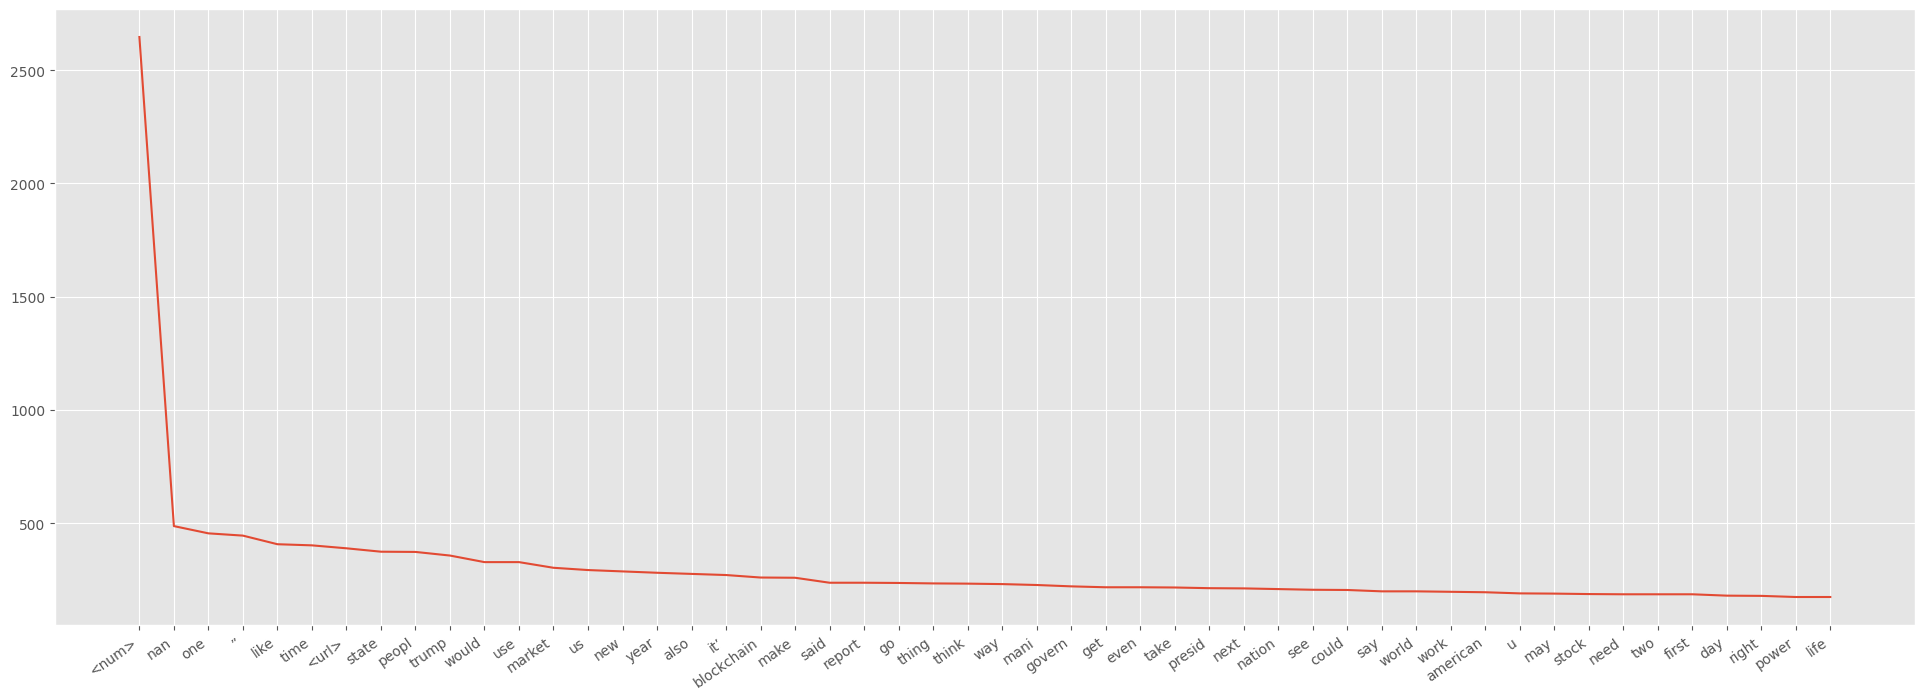

In [11]:
# Make Zipf's law plot of the 50 most common tokens after preprocessing
# Gather all text from NL columns, split into tokens, count
all_text = " ".join(
    df_clean.select(natural_language_cols)
    .fill_null("")
    .unpivot()
    .get_column("value")
    .to_list()
)
from collections import Counter

token_counts = Counter(all_text.split())
most_common = token_counts.most_common(50)
words, counts = zip(*most_common)

plt.figure(figsize=(24, 8))
plt.plot(list(words), list(counts))
plt.xticks(rotation=35, ha="right")
plt.show()

### Task 2 - Bigger subset

In [12]:
# import os
# import Stemmer  # PyStemmer (~10× faster than NLTK)

# #_filepath = "news/data/995,000_rows.csv"
# _outpath = "news/data/995,000_rows_preprocessed.csv"
# _chunk_size = 50_000

# # Preprocess resources (initialized once)
# _stop_words = set(stopwords.words("english"))
# _stemmer = Stemmer.Stemmer("english")

# def _stem_and_filter(x: str) -> str:
#     words = [w for w in x.split() if w not in _stop_words]
#     return " ".join(_stemmer.stemWords(words))

# # Remove old output file if it exists so we can append fresh
# if os.path.exists(_outpath):
#     os.remove(_outpath)

# # Use scan_csv (lazy) and process in chunks to keep memory low
# _lf = pl.scan_csv(_filepath)
# _total_rows = _lf.select(pl.len()).collect().item()
# _n_chunks = (_total_rows + _chunk_size - 1) // _chunk_size
# print(
#     f"Processing {_total_rows} rows in {_n_chunks} chunks of {_chunk_size}..."
# )

# for _i in range(_n_chunks):
#     _offset = _i * _chunk_size
#     # Collect only this chunk from the lazy frame
#     _chunk = (
#         _lf.slice(_offset, _chunk_size)
#         .drop(["id", "Unnamed: 0", "keywords", "summary"])
#         .collect()
#     )
#     # Fill nulls
#     _chunk = _chunk.fill_null("nan")
#     _chunk = _chunk.with_columns(
#         pl.when(pl.col("meta_keywords") == "['']")
#         .then(pl.lit("nan"))
#         .otherwise(pl.col("meta_keywords"))
#         .alias("meta_keywords")
#     )
#     # --- Regex cleaning via native Polars (runs in Rust, not Python) ---
#     _chunk = _chunk.with_columns(
#         [
#             pl.col(col)
#             .str.to_lowercase()
#             .str.replace_all(email_pat, " <EMAIL> ")
#             .str.replace_all(date_pat, " <DATE> ")
#             .str.replace_all(url_pat, " <URL> ")
#             .str.replace_all(num_pat, " <NUM> ")
#             .str.replace_all(special_pat, " ")
#             .str.replace_all(ws_pat, " ")
#             .str.strip_chars()
#             for col in natural_language_cols
#         ]
#     )
#     # --- Stop-word removal + stemming (PyStemmer is C-based, ~10× faster) ---
#     _chunk = _chunk.with_columns(
#         [
#             pl.col(col)
#             .map_elements(_stem_and_filter, return_dtype=pl.String)
#             .alias(col)
#             for col in natural_language_cols
#         ]
#     )
#     # Write: first chunk with header (creates file), rest append without header
#     if _i == 0:
#         _chunk.write_csv(_outpath)
#     else:
#         with open(_outpath, "a") as _f:
#             _chunk.write_csv(_f, include_header=False)
#     print(
#         f"  Chunk {_i + 1}/{_n_chunks} done ({_offset + len(_chunk)} rows so far)"
#     )
#     del _chunk  # Free memory immediately

# print("Done. Preprocessed data saved to", _outpath)

In [13]:
df = pl.read_csv("./data/995,000_rows_preprocessed.csv").to_pandas()
df

,domain,type,url,content,scraped_at,inserted_at,updated_at,title,authors,meta_keywords,meta_description,tags,source
0,nationalreview.com,political,http://www.nationalreview.com/node/152734/%E2%...,plus one articl googl plus thank ali alfoneh a...,2017-11-27T01:14:42.983556,2018-02-08 19:18:34.468038,2018-02-08 19:18:34.468066,iran news round,nan,nation review nation review onlin articl,nan,nan,nan
1,beforeitsnews.com,fake,http://beforeitsnews.com/economy/2012/06/the-c...,cost best senat bank committe jp morgan buy <N...,2017-11-27T01:14:08.7454,2018-02-08 19:18:34.468038,2018-02-08 19:18:34.468066,cost best senat bank committe jp morgan buy <N...,nan,nan,nan,nan,nan
2,dailycurrant.com,satire,http://dailycurrant.com/2016/01/18/man-awoken-...,man awoken <NUM> -year coma commit suicid lear...,2017-11-27T01:14:21.395055,2018-02-07 23:39:33.852671,2018-02-07 23:39:33.852696,man awoken <NUM> -year coma commit suicid lear...,nan,nan,nan,nan,nan
3,nytimes.com,reliable,https://query.nytimes.com/gst/fullpage.html?re...,julia geist ask draw pictur comput scientist l...,2018-02-11 00:46:42.632962,2018-02-11 00:14:20.346838,2018-02-11 00:14:20.346871,open gateway girl enter comput field,nan,comput internet women girl career profess mill...,julia geist ask draw pictur comput scientist l...,nan,nytimes
4,infiniteunknown.net,conspiracy,http://www.infiniteunknown.net/2011/09/14/100-...,<NUM> compil studi vaccin danger activist post...,2017-11-10T11:18:44.524042,2018-02-07 23:39:33.852671,2018-02-07 23:39:33.852696,<NUM> compil studi vaccin danger infinit unknown,nan,nan,nan,"Lymphoma, Hepatitis B, Immune System, Health, ...",nan
...,...,...,...,...,...,...,...,...,...,...,...,...,...
994995,21stcenturywire.com,conspiracy,http://21stcenturywire.com/tag/kony-2012/,<NUM> wire intervent watch say anyon sign avaa...,2017-11-09T12:48:34.461199,2018-02-07 23:39:33.852671,2018-02-07 23:39:33.852696,koni <NUM> archiv,nan,nan,nan,"Michelle Obama, Drones, Selfie, Uganda, smart ...",nan
994996,nationalreview.com,political,http://www.nationalreview.com/node/152734/%E2%...,plus one articl googl plus thank ali alfoneh a...,2017-11-27T01:14:42.983556,2018-02-08 19:18:34.468038,2018-02-08 19:18:34.468066,iran news round,nan,nation review nation review onlin articl,nan,nan,nan
994997,thesaker.is,unknown,http://thesaker.is/china-and-russia-are-acquir...,china russia acquir gold dump us dollar evid c...,2017-11-18T20:01:27.400599,2018-02-07 23:39:33.852671,2018-02-07 23:39:33.852696,china russia acquir gold dump us dollar,saker,nan,bird eye view vineyard,"Gold, Dollar, Russia, China",nan
994998,express.co.uk,rumor,https://www.express.co.uk/pictures/sport/6708/...,liverpool sign sadio mane southampton fan reac...,2017-11-27T01:14:33.570665,2018-02-08 19:18:34.468038,2018-02-08 19:18:34.468066,twitter react liverpool sign sadio mane,nan,nan,express sport bring best tweet liverpool confi...,nan,nan


In [18]:
# 1. counting the number of URLs in the content
import sys

vocab = {}
for idx,col in enumerate(natural_language_cols):
    sys.stdout.write(f'\rCols: {idx+1}/{len(natural_language_cols)}')
    for cell in df[col]:
        for w in cell.split():
            if w in vocab:
                vocab[w] += 1
            else:
                vocab[w] = 1

vocab = {k:val for k,val in sorted(vocab.items(), key=lambda item: item[1], reverse=True)}
vocab = pd.DataFrame({'token': list(vocab.keys()), 'count': list(vocab.values())}).set_index('token')
keep_ptn = re.compile(r'[-–/\'"()<>]')
vocab = vocab[vocab.reset_index()['token'].apply(lambda x: re.sub(keep_ptn, '', x).isalpha()).values]
vocab = vocab[vocab['token'].apply(lambda x : len(x) <= 30)]
vocab.head(30)

Cols: 5/5

,count
token,
<NUM>,9945531
nan,1623238
said,1441500
new,1185407
one,1136767
time,1008202
state,1004180
would,978282
year,949692


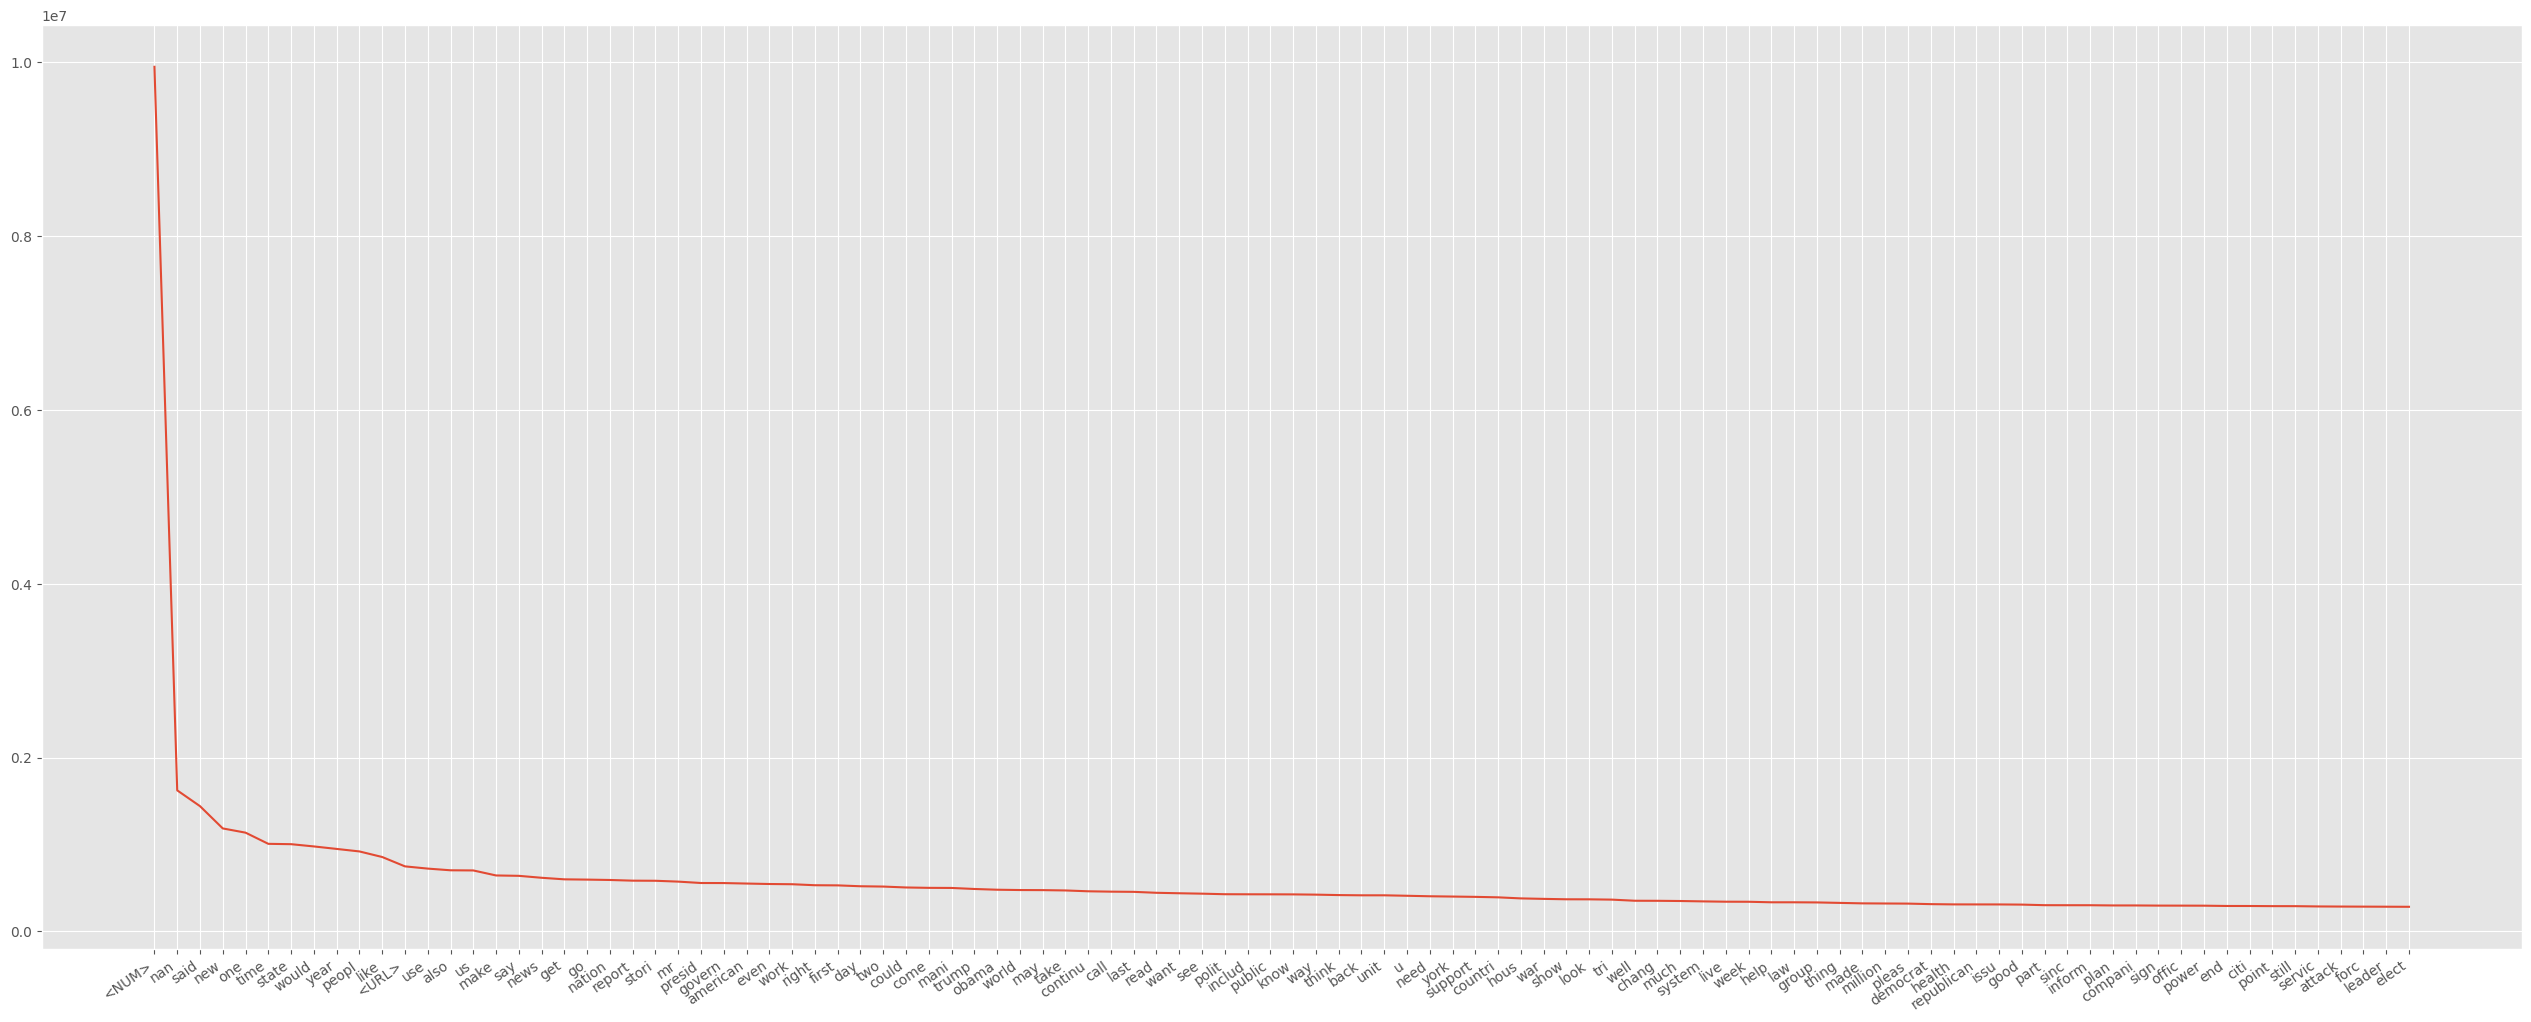

In [19]:
top_vocab = vocab.head(100)
plt.figure(figsize=(32,12))
plt.plot(top_vocab['count'])
plt.xticks(top_vocab.index)
plt.xticks(rotation=35, ha='right')
plt.show()

In [20]:
vocab.reset_index().query('token == "trump"')

,token,count
36,trump,488984


<br><h1 style='text-align: center;'>Task 3</h1><br>

In [22]:
special_tokens = ['<URL>','<EMAIL>','<DATE>','<NUM>']
vocab[vocab.reset_index()['token'].apply(lambda x: x in special_tokens).values]

,count
token,
<NUM>,9945531
<URL>,749048
<DATE>,81881
<EMAIL>,22536


In [46]:
# size of vocabulary
keep_vocab = vocab[:10000]
keep_vocab

,token,count
0,<NUM>,9945531
1,nan,1623238
2,said,1441500
3,new,1185407
4,one,1136767
...,...,...
9995,avec,1906
9996,unexplain,1905
9997,takfiri,1905
9998,quicker,1905


In [53]:
# words containing dashes
float(vocab['token'].apply(lambda x : '-' in x).sum() / vocab.shape[0]) * 100.0

30.137044176615657

In [55]:
vocab[vocab['token'].apply(lambda x : '-' in x)].head(30)

,token,count
745,-year-old,82060
915,re-ent,67631
1697,e-mail,32552
1703,so-cal,32476
1711,iran-iraq,32355
1720,pre-islam,32121
1726,iranian-mad,32061
1734,gholam-ali,32016
1735,aftab-,32013
1736,habib-allah,32012


In [61]:
float(vocab[vocab['token'].apply(lambda x : '-' in x)]['count'].sum() / vocab['count'].sum()) * 100.0

1.5922766913413897

<br><h3 style='text-align: center;'>Making Non-Trivial Discoveries</h3><br>

### 1. Urban Words
As it turns out, simply by looking at the 100 most common non-stopwords, we see that a lot of them are related to the so-called "urban" lifestyle. We may consider the following clusters:
- Geographical: 'world', 'states', 'york', 'countri', 'nation', 'citi'
- Political: 'govern', 'trump', 'obama', 'democrat', 'republican', 'war', 'leader', 'mr', 'presid', 'system', 'elect'
- Temporal: 'time', 'new', 'first', 'year', 'week', 'night'
- Journalism: 'news', 'report', 'stori'
- Corporate: 'compani', 'million', 'made', 'make', 'offic', 'read', 'law', 'plan'
- Health & Home: 'health', 'house', 'live', 'see'

### 2. Combining Words
Lots of words were combinations of other words using dashes ("-"). This seems pretty surprising, as most of the time, dash-words seem quite uncommon, but in the million articles, words containing dashes made up $30.13\%$ of words in the vocabulary, despite only making up $1.592\%$ of words used in general, which is still quite substantial. <br>
Here, the top-words containing dashes were words like "x-year-old", "e-mail", "long-term", "so-called",  and other more political ones like "iran-iraq", "pre-islam", "re-elect", "re-entry", "white-list", "same-sex", "anti-semit", "presedent-elect", "right-wing".

### 3. Letter placements
One of the noteworthy things about having access to a news-corpus of this magnitude, is that it allows you to study language and word-use as a whole. This means we have a great opportunity to answer interesting questions related to letter-use in the English language. In psychology-class, I remembered a study by Daniel Kahneman and Amos Tversky highlighting the availability bias. <br><br> They would do this by asking so-called "free-thinkers", whether English words were more likely to start with the letter "k" or to contain "k" as the third letter. In the study, most participants would answer the former, naming words like "king", "knee", "kid", "kick", but Tversky and Kahneman argued that "k" was actually more common as a third-letter because of words like "acknowledge","cake","makeover". Many of the participants would "forget the fact that "k" is a very common third-letter", because it's not as readily available in ones mind. I however, believe that "k" is more common as the fourth letter, as when paired up with a consonant, a vowel and a "c", you get words such as "hacker", "fucked", "cuck", "lock", "backpack". <br><br> I wanted to investigate this for myself, so I counted the distribution of positions for every letter using our vocabulary.

In [121]:
# distribution over letter-positions
letters = ' '.join('abcdefghijklmnopqrstuvwxyz-').split()
pos_counts = {l:[0 for i in range(10)] for l in letters}

for _,(token,count) in vocab.iterrows():
    for idx,letter in enumerate(token[:10]):
        if letter in pos_counts:
            pos_counts[letter][idx] += count

pos_counts = pd.DataFrame(pos_counts, index=list(range(1,11))).transpose()
pos_counts

,1,2,3,4,5,6,7,8,9,10
a,18848916,41139175,23819292,14816394,12865045,8426586,5138574,2372979,1574301,751997
b,12208238,1917495,4161125,2710009,1690389,1429722,534505,288558,77895,46953
c,24279781,4500919,12541243,8664306,7794227,6169136,2629862,1410497,398872,207412
d,12620922,2858155,7958244,11850441,7120702,6225302,1950702,1163658,683047,571283
e,11782743,47137948,21024399,36558851,25574935,7540207,3298918,1589851,526010,320641
f,12237884,2012154,4862559,2467358,1347380,964761,370640,232692,115860,43087
g,8905291,1197722,6830624,5257744,4611729,2033067,1664401,801316,394945,193393
h,8438122,10222437,2079885,6353667,5112254,3218210,1341045,1067640,567201,390577
i,9755439,26337400,16285951,20998544,20501533,11103009,8523638,3305843,1855717,1084130
j,3317037,55216,612855,332815,50997,30294,14896,14573,41111,3935


C:\Users\dinne\AppData\Local\Temp\ipykernel_3020\3288195836.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  letter_freqs = pos_counts.sum(1).sort_values(ascending=False)


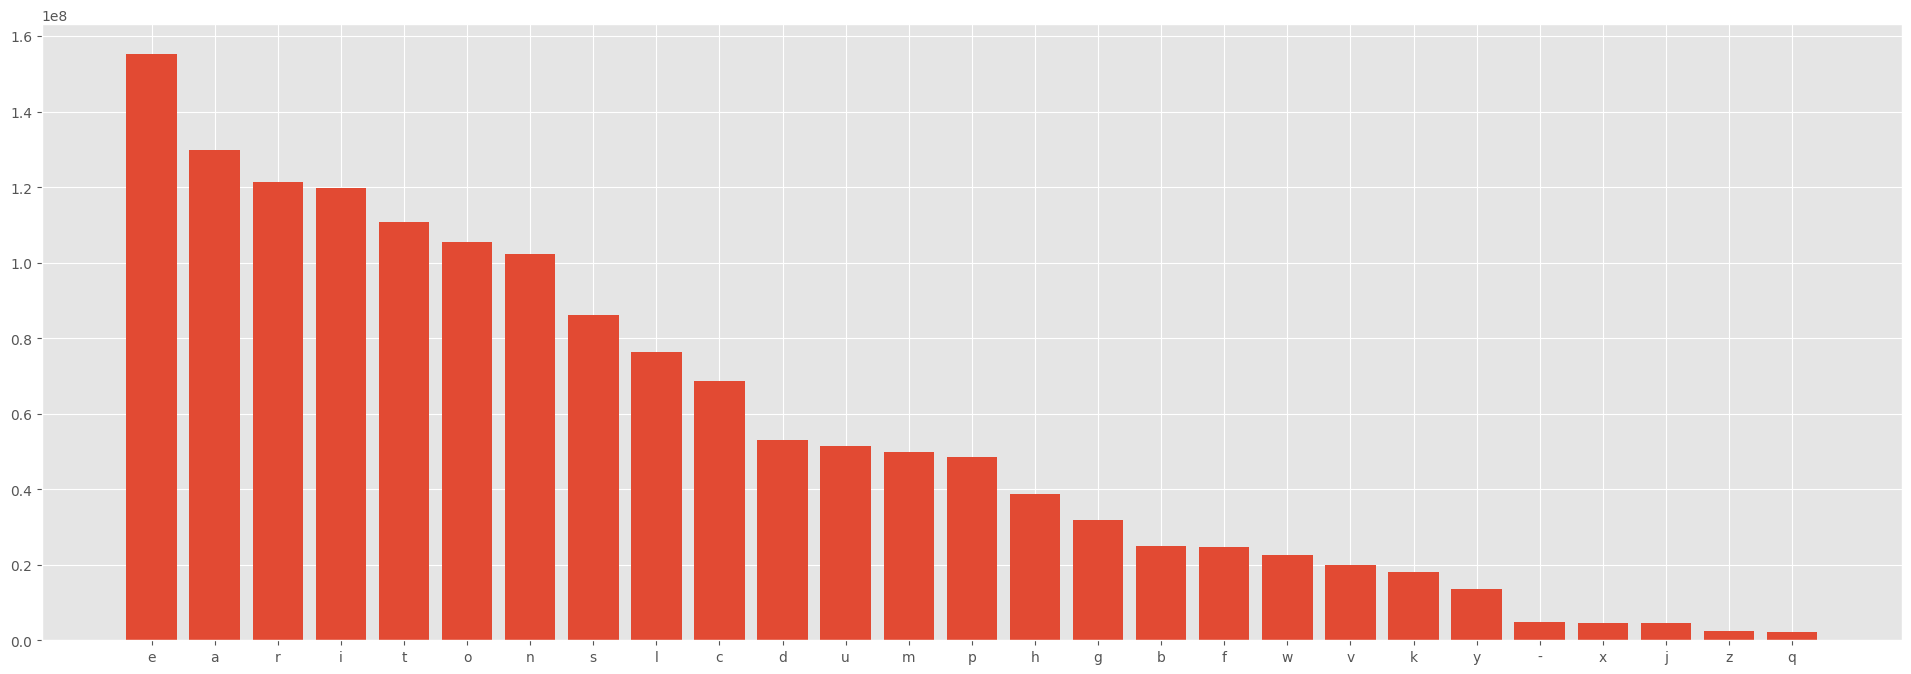

In [128]:
# first we rank the letters based on highest frequency to actually find most common letter rankings
letter_freqs = pos_counts.sum(1).sort_values(ascending=False)
plt.figure(figsize=(24,8))
plt.bar(letter_freqs.index, letter_freqs.values)
plt.show()

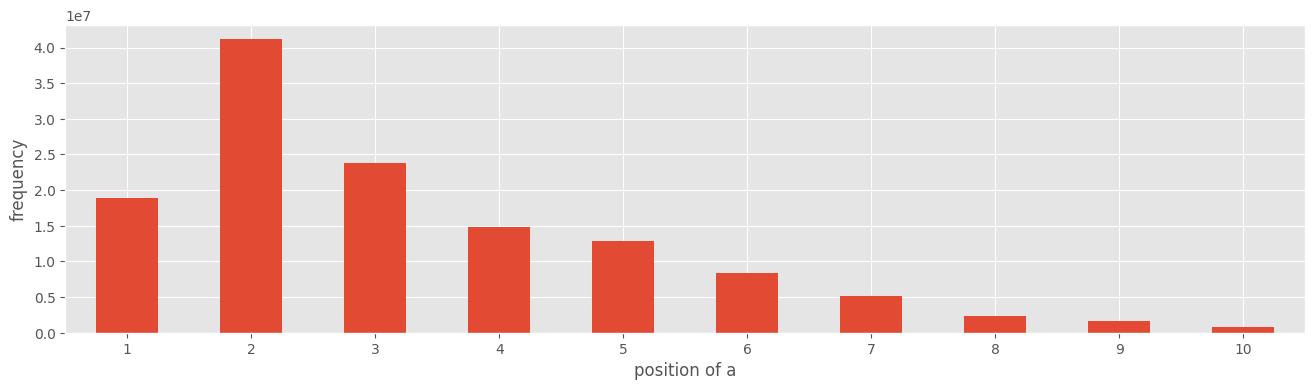

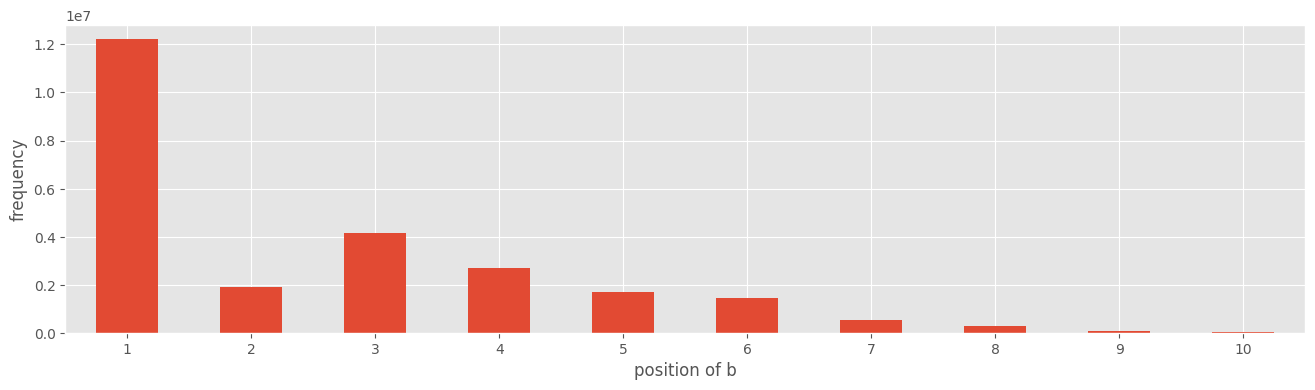

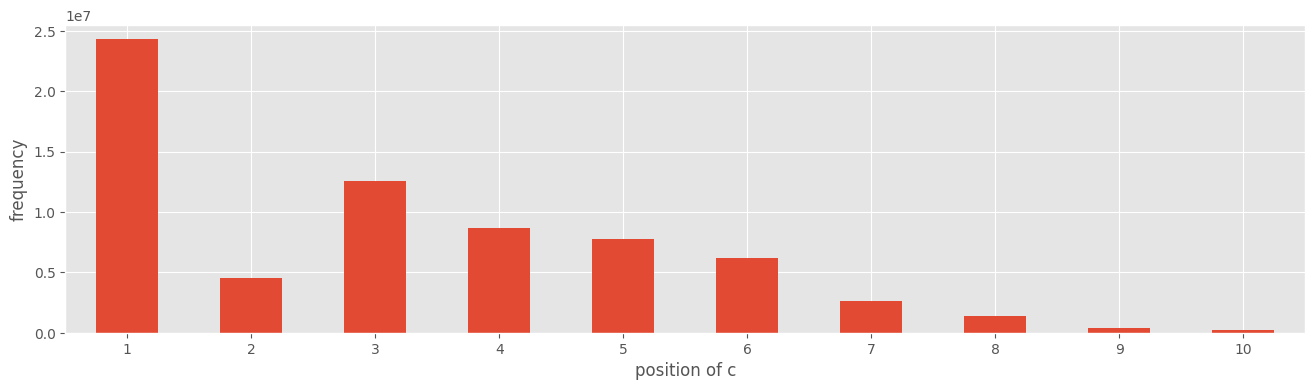

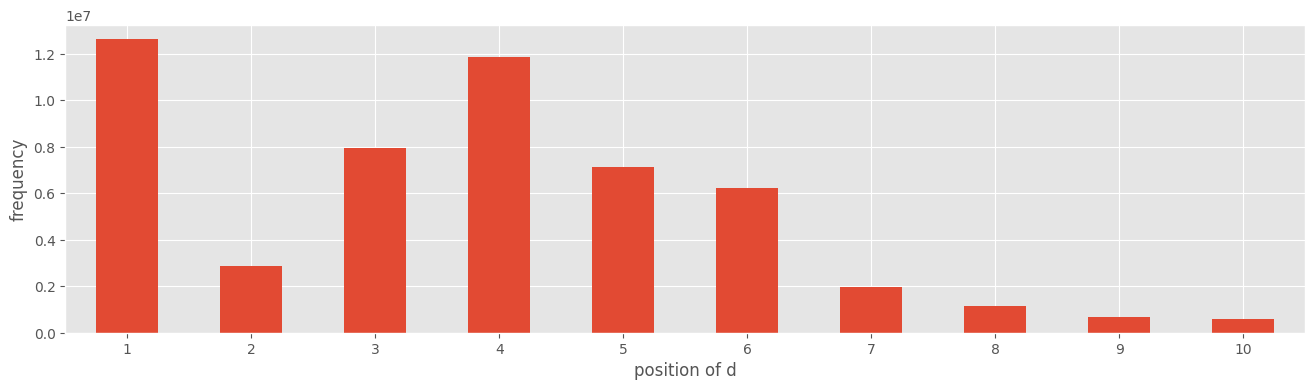

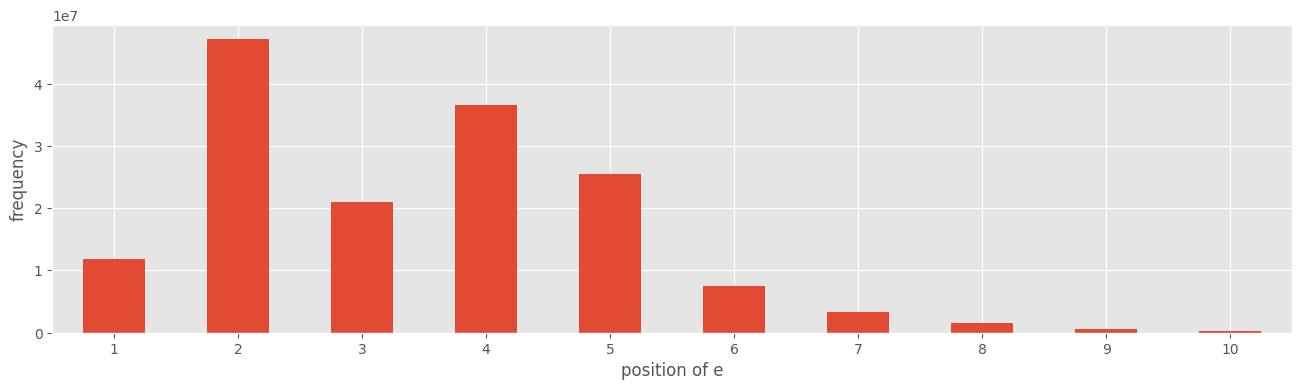

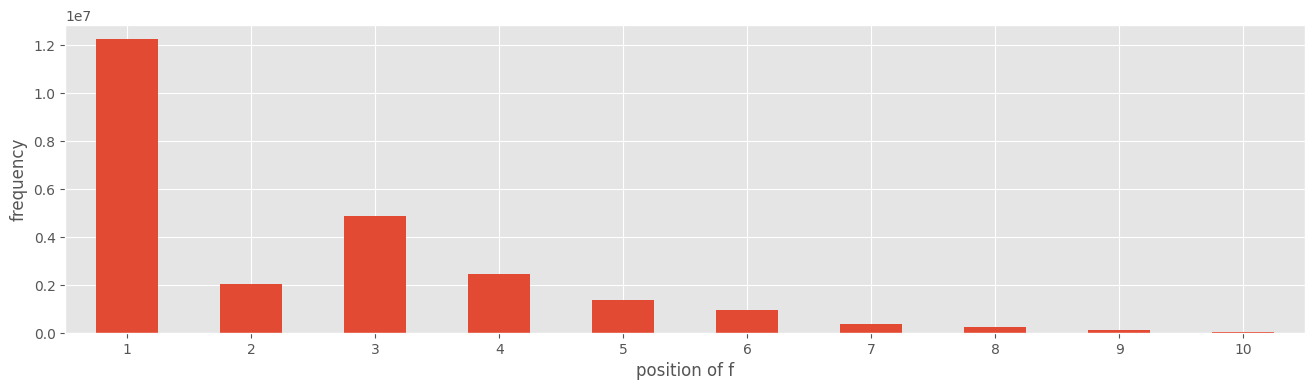

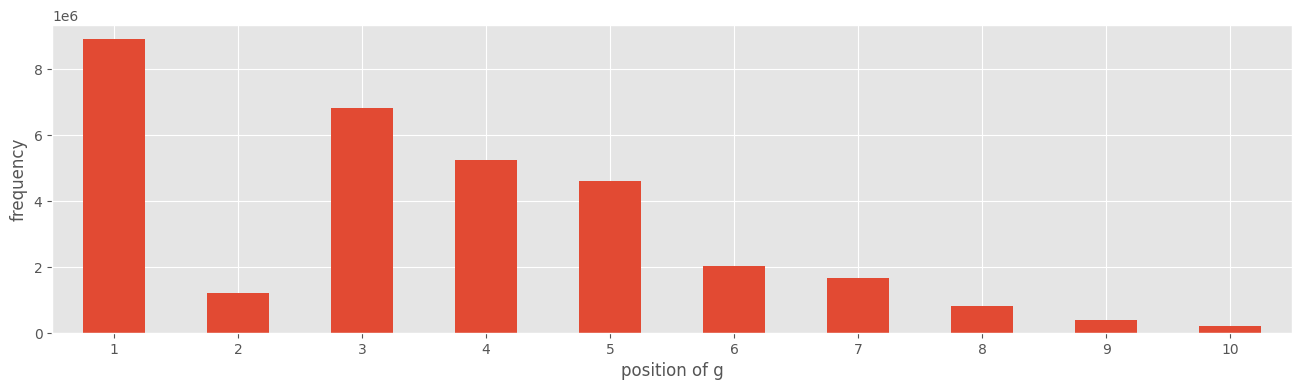

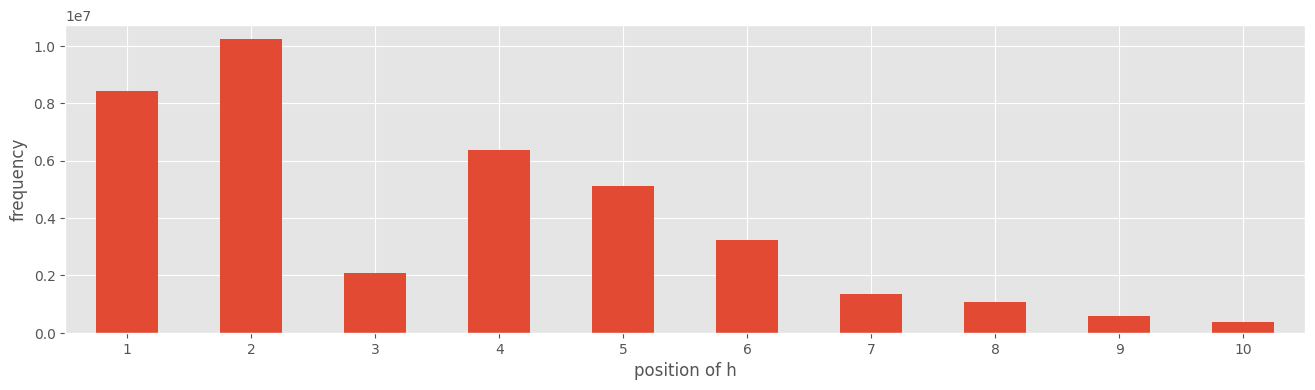

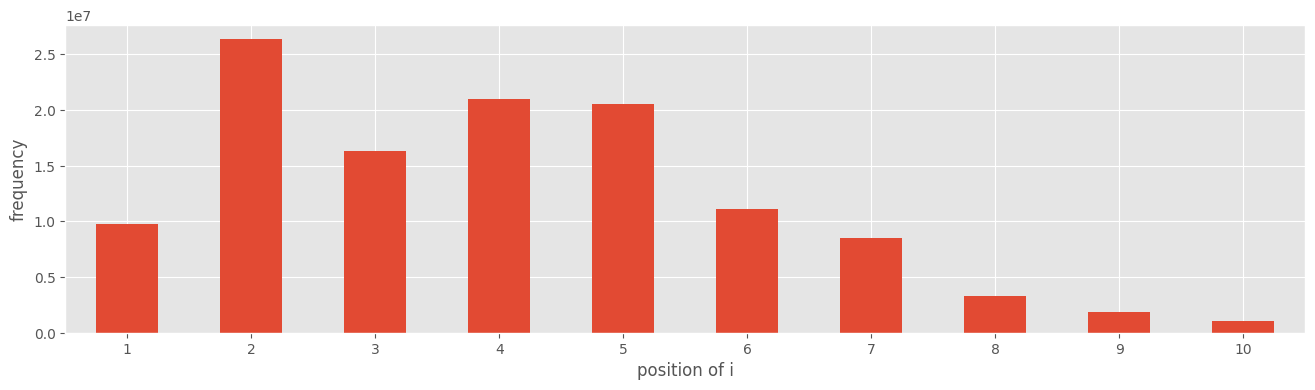

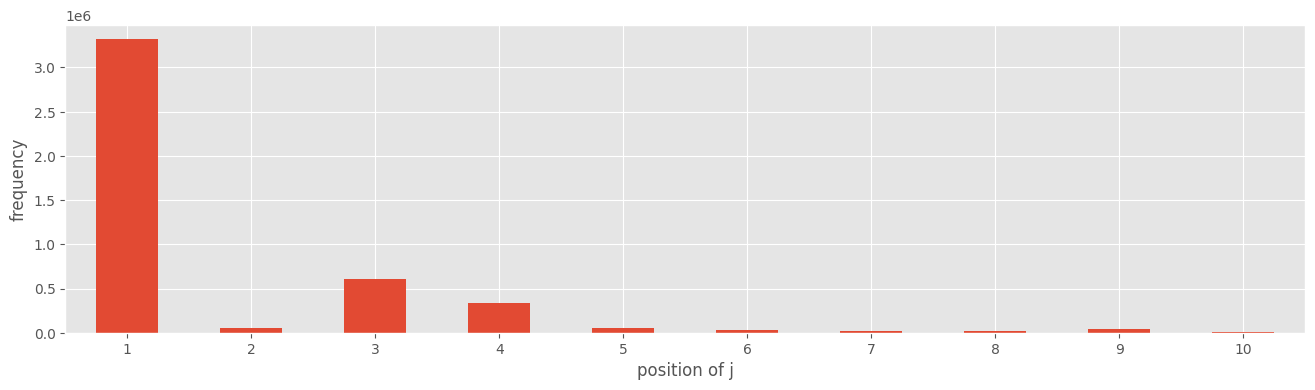

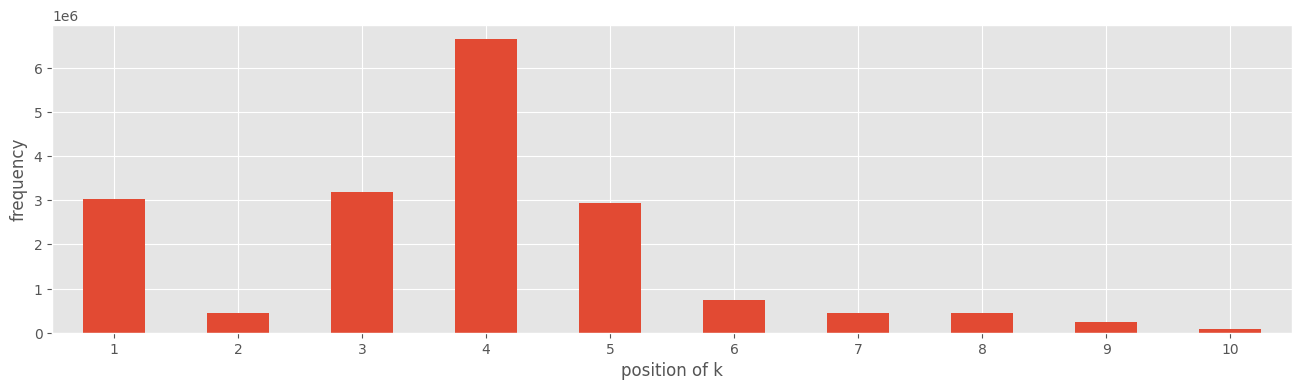

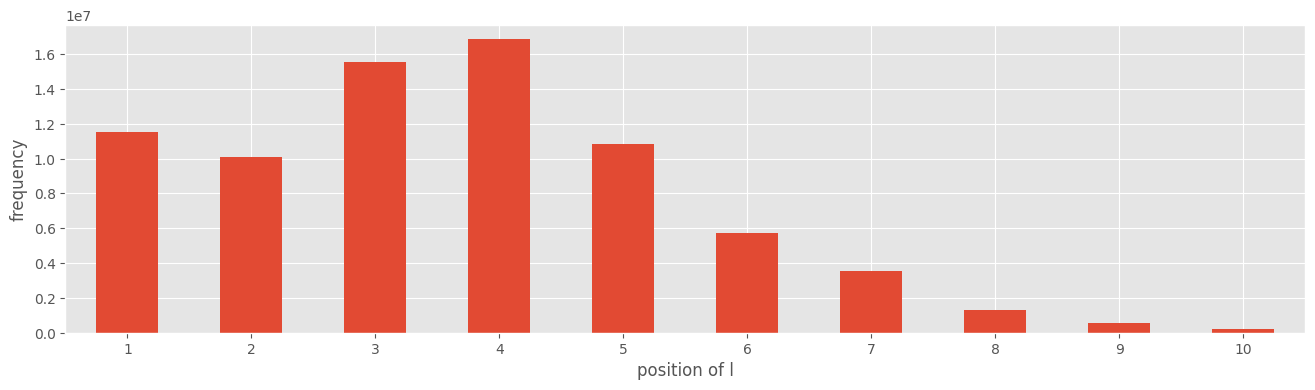

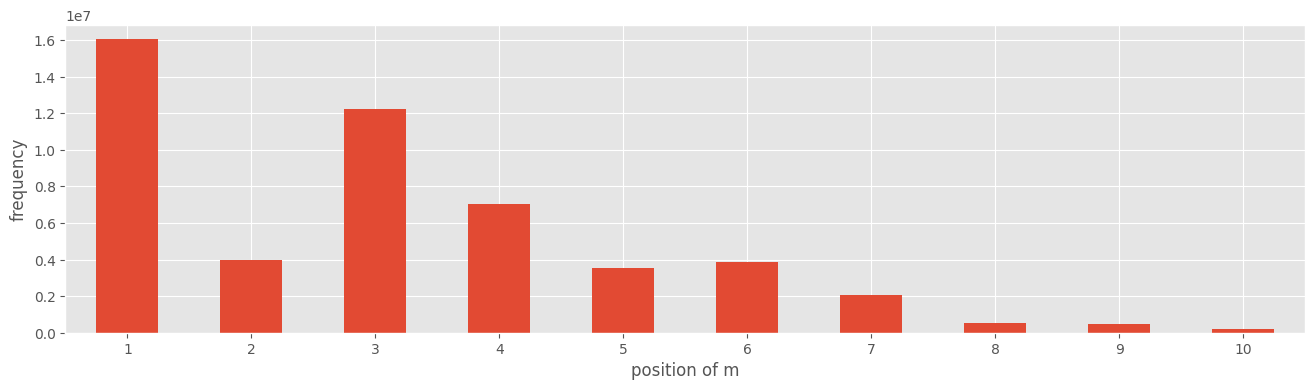

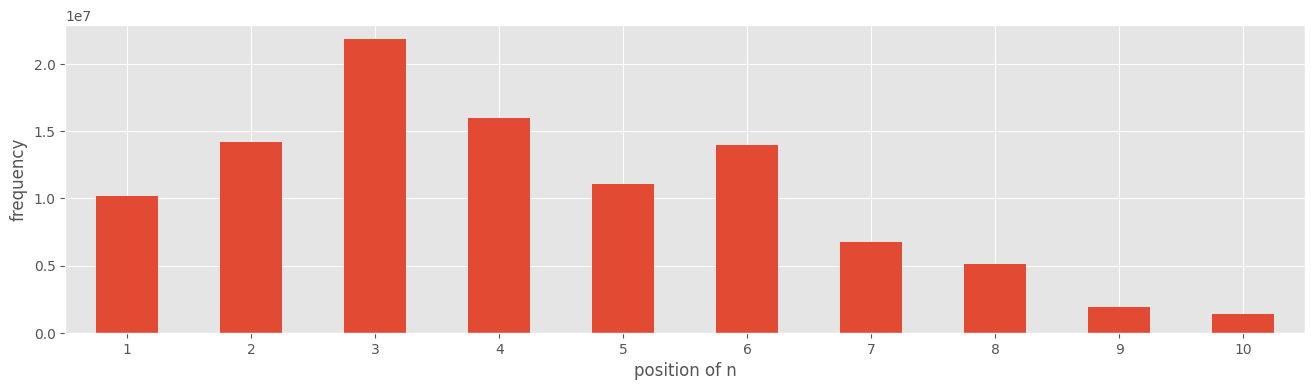

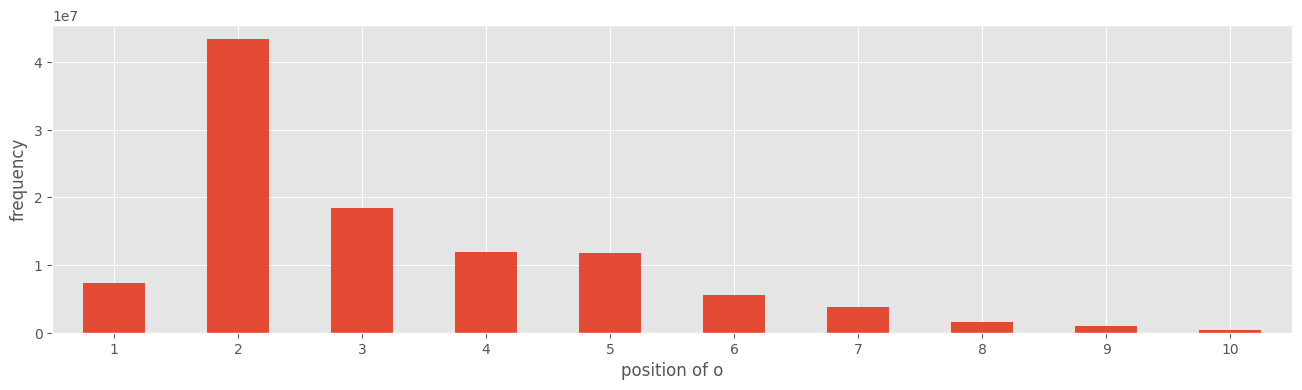

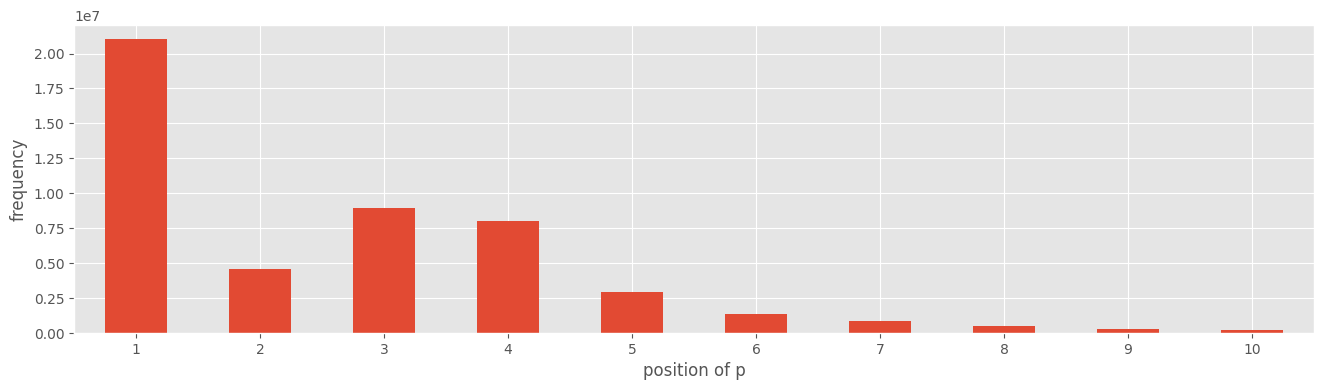

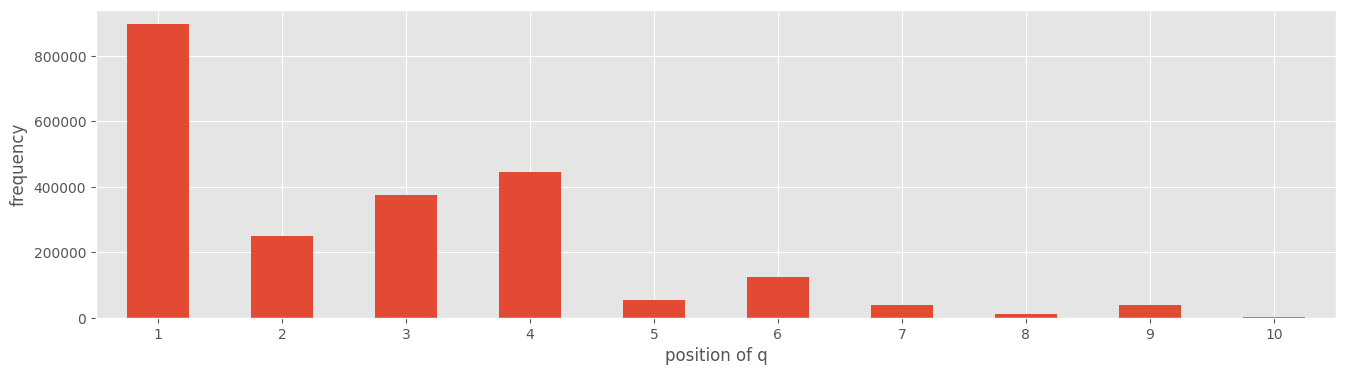

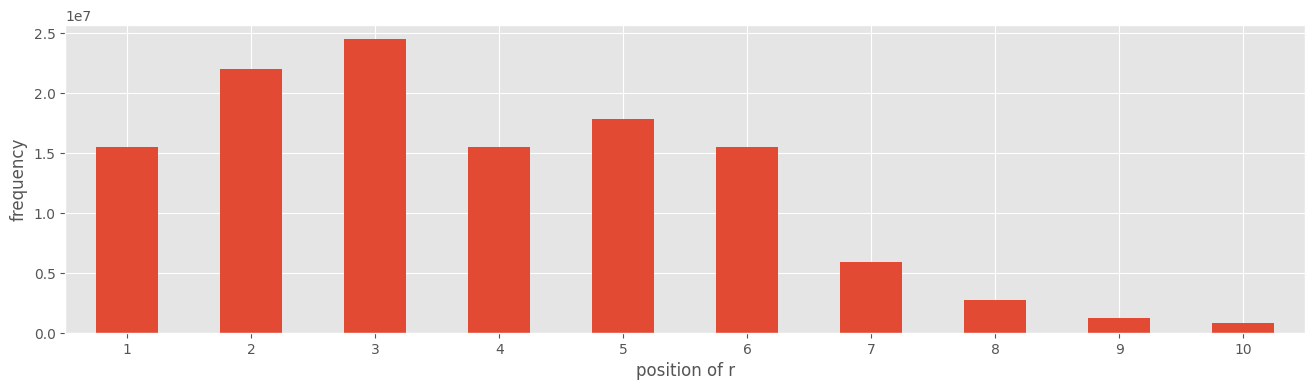

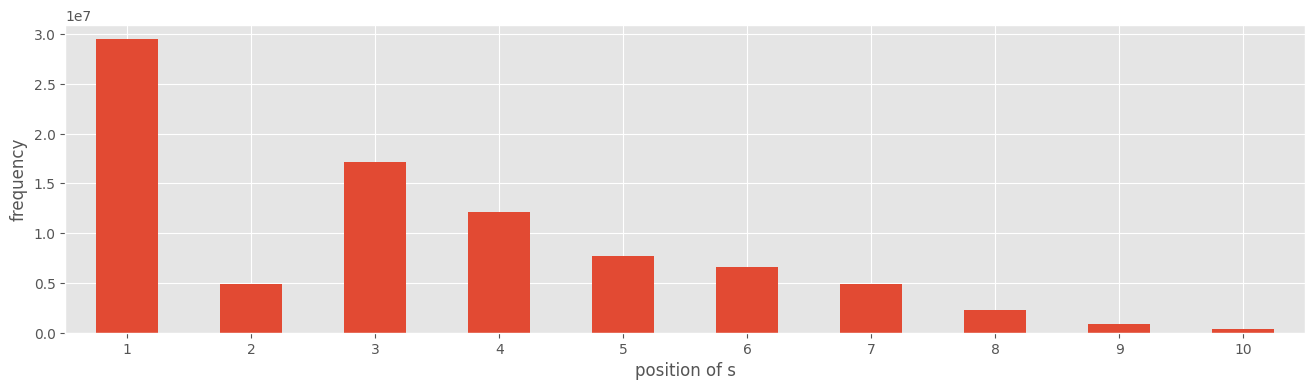

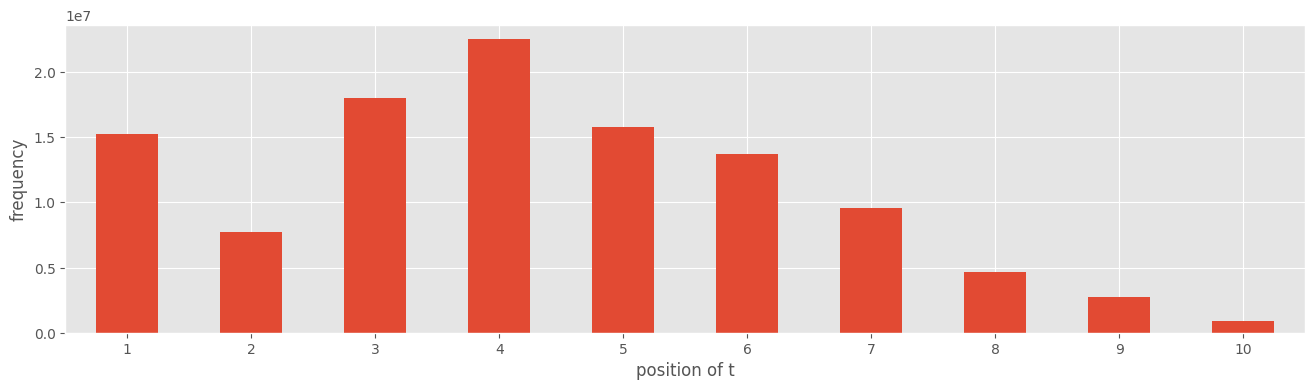

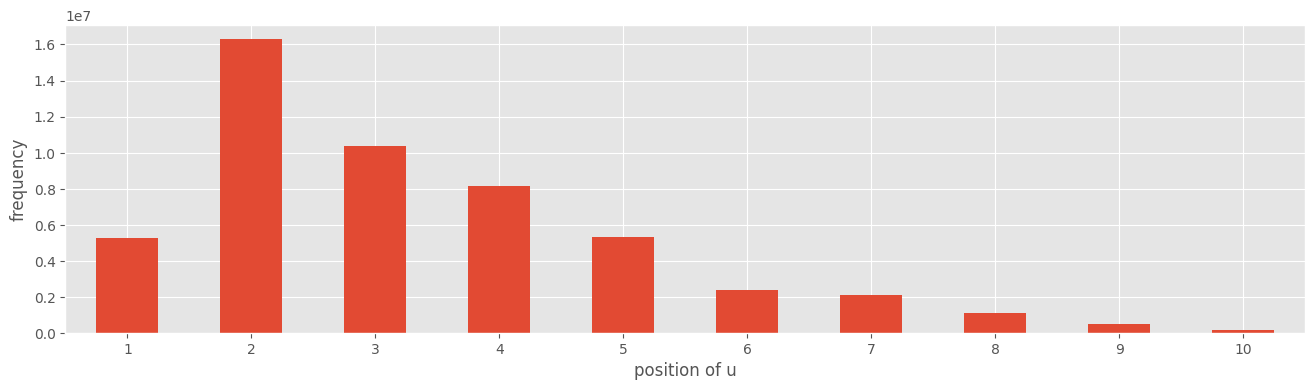

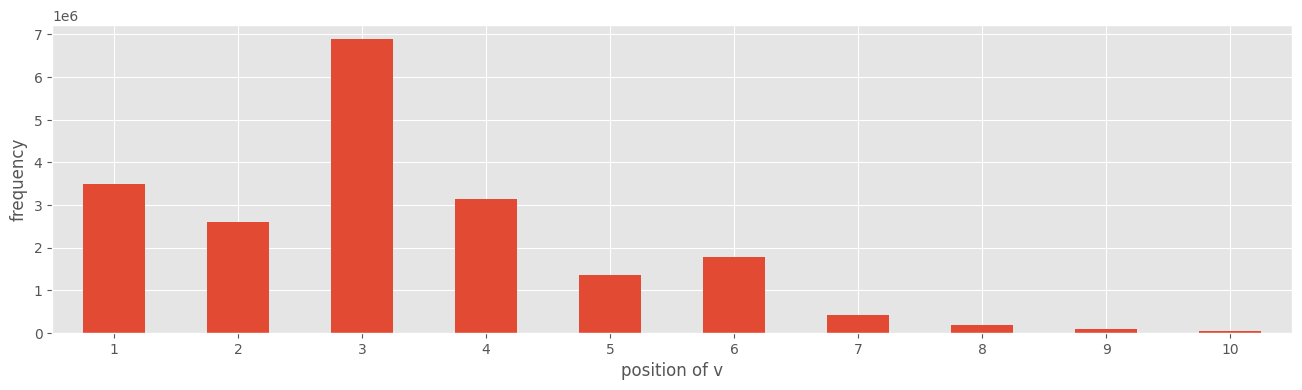

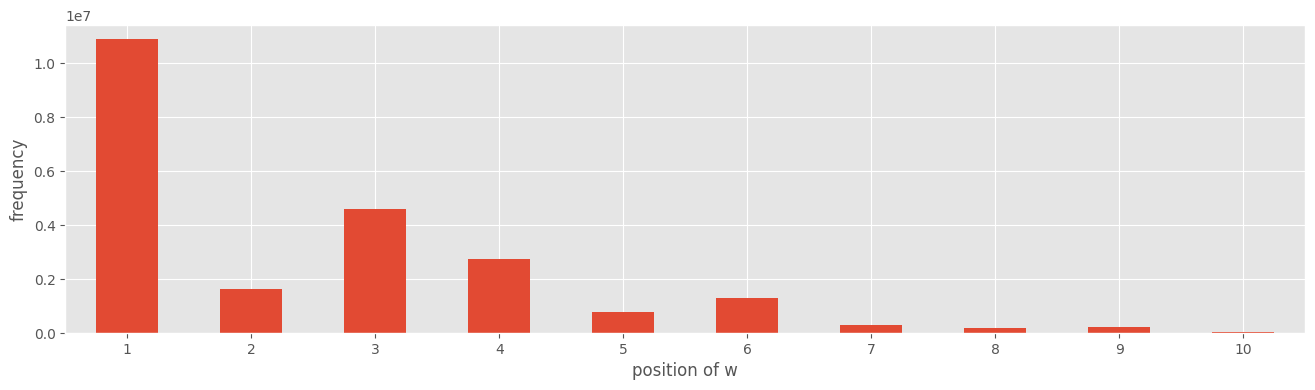

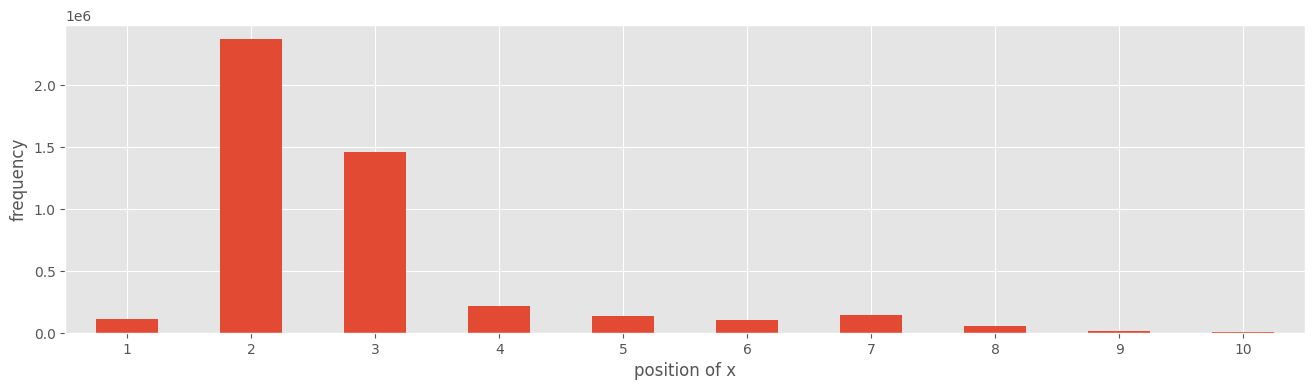

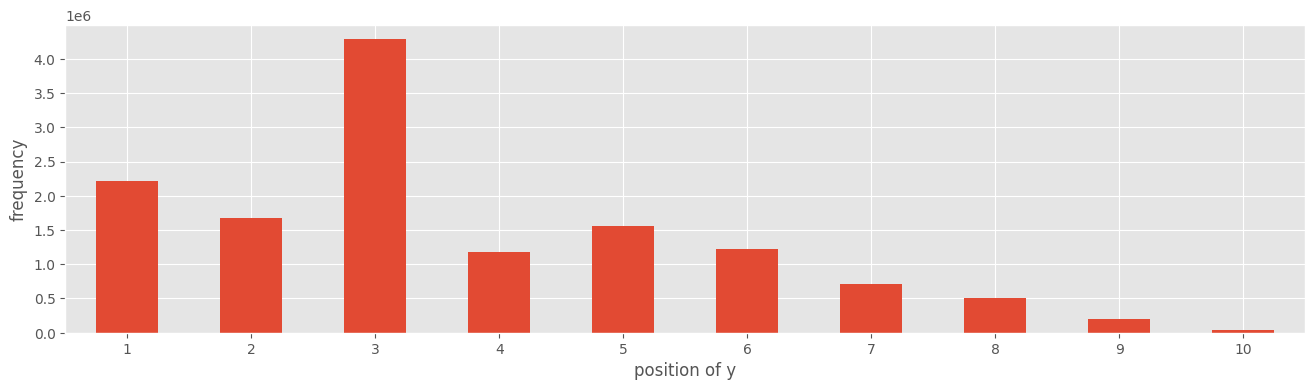

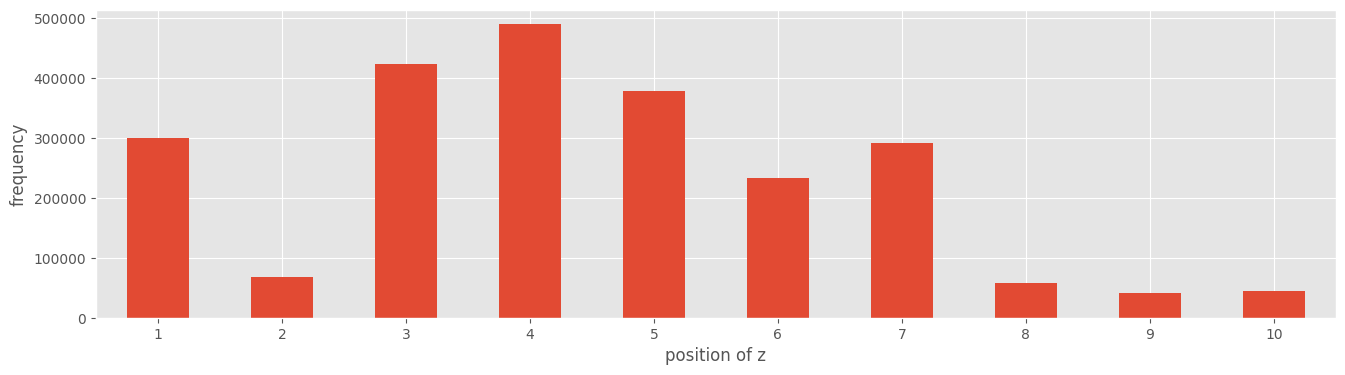

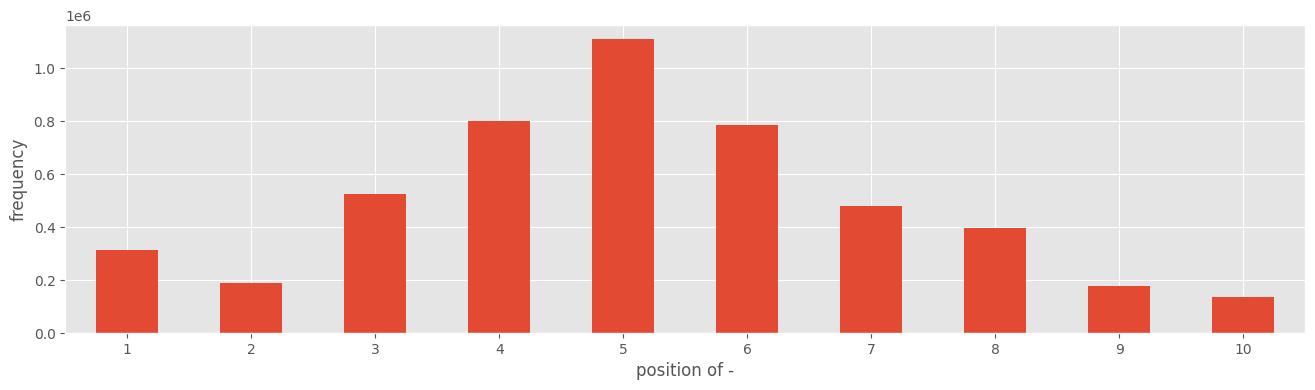

In [126]:
for l in letters:
    pos_counts.loc[l].plot(kind='bar', figsize=(16,4))
    plt.xticks(rotation=0)
    plt.xlabel(f'position of {l}')
    plt.ylabel('frequency')
    
    plt.show()

### Overview
From this investigation, we can conclude many interesting and surprising results.

- We observed that Tversky and Kahneman were in fact **wrong**, as $k$ appeared more than twice as frequently in the fourth position as in the first, while only appearing slightly more commonly in the third position.

- Another surprising result is that $e,a$ are in fact the most frequently used letters, meaning when playing hangman, they should actually be your first guesses.

- Very surprisingly, the letter $z$ appears almost as frequently in the 7'th position as in the first. It also appeared the most frequently in the 3rd, 4th, and 5th positions.

### 4. News-length
The distribution of the length of articles and the words they use

### 5. Content readability
Calculating the lix-coefficient for each article before vs after it is cleaned

### 6. Something interesting